# Problem Statement

 # Goal

# Importing all the necessary library 

In [113]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as mm
import seaborn as sns

In [114]:
df=pd.read_csv("D:\\PIYUSH KUMAR MISHRA\\Fourth_SEM\\ML_YogeshSir\\Dynamic Pricing Model\\dynamic_pricing.csv")
df.head() # you can also open in excel for understanding data deeply

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


# Data Assessment

In [115]:
df.shape

(1000, 10)

In [116]:
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [118]:
#verifying the null values
df.isnull().sum()

Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64

In [119]:
df[df.duplicated()]# No duplicated are present 

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride


# Column Names Inspection

In [120]:
df.columns

Index(['Number_of_Riders', 'Number_of_Drivers', 'Location_Category',
       'Customer_Loyalty_Status', 'Number_of_Past_Rides', 'Average_Ratings',
       'Time_of_Booking', 'Vehicle_Type', 'Expected_Ride_Duration',
       'Historical_Cost_of_Ride'],
      dtype='object')

In [121]:
#Unique Values in Categorical Variables

In [122]:
categorical_columns=df.select_dtypes(include='object').columns

In [123]:
categorical_columns

Index(['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking',
       'Vehicle_Type'],
      dtype='object')

In [124]:
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


Location_Category
['Urban' 'Suburban' 'Rural']

Customer_Loyalty_Status
['Silver' 'Regular' 'Gold']

Time_of_Booking
['Night' 'Evening' 'Afternoon' 'Morning']

Vehicle_Type
['Premium' 'Economy']


In [125]:
#Statistically summary
df.describe().T

# Here we are assesing mean,median,std ,variance and other statistics measure to prevent issues
# Example if rating>5 then issue because here max rating is 5 only

,count,mean,std,min,25%,50%,75%,max
Number_of_Riders,1000.0,60.372000,23.701506,20.000000,40.000000,60.000000,81.000000,100.000000
Number_of_Drivers,1000.0,27.076000,19.068346,5.000000,11.000000,22.000000,38.000000,89.000000
Number_of_Past_Rides,1000.0,50.031000,29.313774,0.000000,25.000000,51.000000,75.000000,100.000000
Average_Ratings,1000.0,4.257220,0.435781,3.500000,3.870000,4.270000,4.632500,5.000000
Expected_Ride_Duration,1000.0,99.588000,49.165450,10.000000,59.750000,102.000000,143.000000,180.000000
Historical_Cost_of_Ride,1000.0,372.502623,187.158756,25.993449,221.365202,362.019426,510.497504,836.116419


# Outlier Assessment

Index(['Number_of_Riders', 'Number_of_Drivers', 'Number_of_Past_Rides',
       'Average_Ratings', 'Expected_Ride_Duration', 'Historical_Cost_of_Ride'],
      dtype='object')


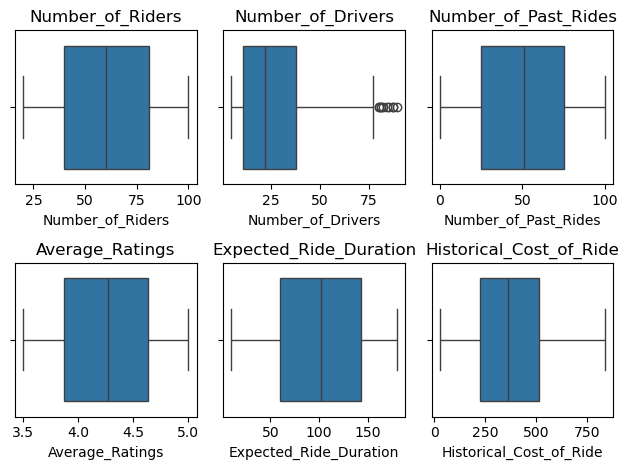

In [126]:
numerical_columns=df.select_dtypes(include=['int64','float64']).columns
print(numerical_columns)
for i,col in enumerate(numerical_columns,1):
    mm.subplot(2,3,i)
    sns.boxplot(x=df[col])
    mm.title(col)
mm.tight_layout()
mm.show()

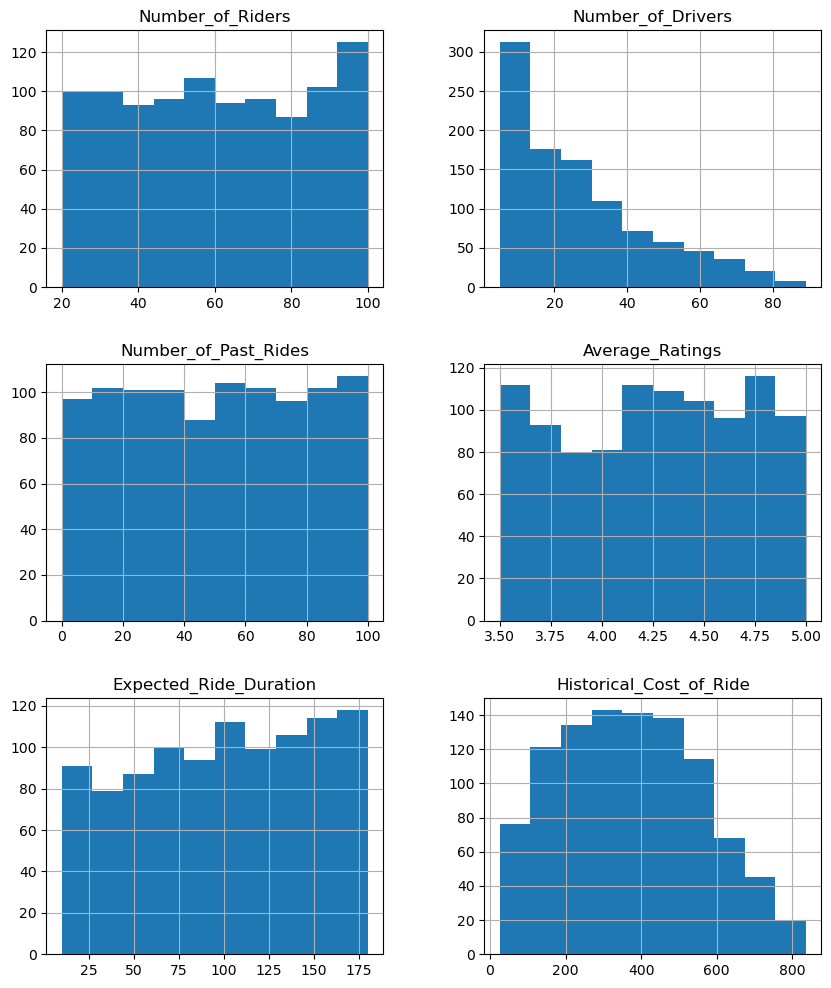

In [127]:
#distribution checking
df.hist(figsize=(10,12))
mm.show()

In [128]:
# Categorical feature assessment
for col in categorical_columns:
    print(f"{col}")
    print(df[col].value_counts())

Location_Category
Location_Category
Urban       346
Rural       332
Suburban    322
Name: count, dtype: int64
Customer_Loyalty_Status
Customer_Loyalty_Status
Silver     367
Regular    320
Gold       313
Name: count, dtype: int64
Time_of_Booking
Time_of_Booking
Night        276
Afternoon    247
Morning      246
Evening      231
Name: count, dtype: int64
Vehicle_Type
Vehicle_Type
Premium    522
Economy    478
Name: count, dtype: int64


In [129]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Number_of_Riders,1000.0,NaN,NaN,NaN,60.372,23.701506,20.0,40.0,60.0,81.0,100.0
Number_of_Drivers,1000.0,NaN,NaN,NaN,27.076,19.068346,5.0,11.0,22.0,38.0,89.0
Location_Category,1000,3,Urban,346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Loyalty_Status,1000,3,Silver,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number_of_Past_Rides,1000.0,NaN,NaN,NaN,50.031,29.313774,0.0,25.0,51.0,75.0,100.0
Average_Ratings,1000.0,NaN,NaN,NaN,4.25722,0.435781,3.5,3.87,4.27,4.6325,5.0
Time_of_Booking,1000,4,Night,276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,1000,2,Premium,522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Expected_Ride_Duration,1000.0,NaN,NaN,NaN,99.588,49.16545,10.0,59.75,102.0,143.0,180.0
Historical_Cost_of_Ride,1000.0,NaN,NaN,NaN,372.502623,187.158756,25.993449,221.365202,362.019426,510.497504,836.116419


# Data Cleaning Steps 
- Remove outliers from Number_of_Drivers(But it is due to festival season, airport areas  etc)

# Data Assessment and Cleaning

The dataset was assessed for structural and quality-related issues.

### Data Assessment Performed:
- Missing value detection
- Duplicate row checking
- Data type verification
- Statistical summary analysis
- Distribution analysis
- Outlier detection
- Categorical consistency checking

### Key Findings:
- No missing values were present.
- No duplicate records were identified.
- All variables had appropriate data types.
- Categorical variables were balanced and consistent.
- Outliers were observed in `Number_of_Drivers`, but retained as they represent realistic ride-sharing operational scenarios.

### Cleaning Decision:
No significant cleaning was required. The dataset was considered suitable for exploratory data analysis and predictive modeling.

# EDA

In [130]:
# Skewness Analysis
df.skew(numeric_only=True)
#Number_of_Drivers is right skewed
#it indicates that higher number of drivers appear less frequently

Number_of_Riders           0.002167
Number_of_Drivers          0.963204
Number_of_Past_Rides      -0.008457
Average_Ratings           -0.078754
Expected_Ride_Duration    -0.139868
Historical_Cost_of_Ride    0.209580
dtype: float64

In [131]:
print(df.corr(numeric_only=True)['Historical_Cost_of_Ride'].sort_values(ascending=False))

Historical_Cost_of_Ride    1.000000
Expected_Ride_Duration     0.927547
Number_of_Past_Rides       0.035859
Number_of_Drivers          0.017082
Number_of_Riders           0.005826
Average_Ratings           -0.001063
Name: Historical_Cost_of_Ride, dtype: float64


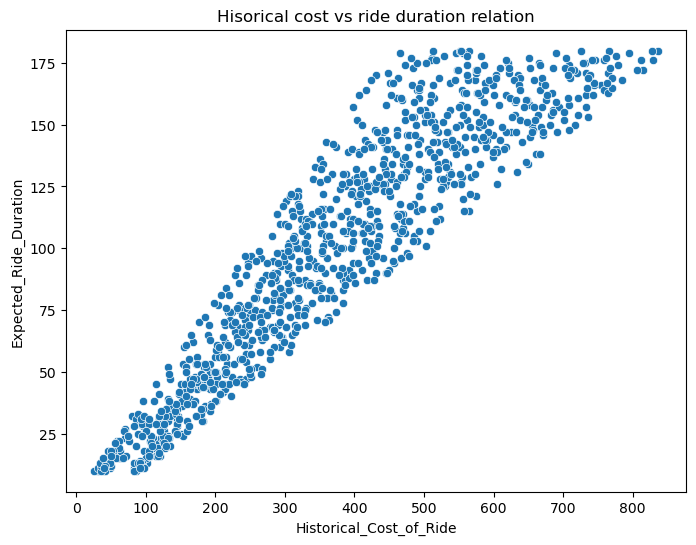

In [132]:
# check this visually using scatter plot
mm.figure(figsize=(8,6))
sns.scatterplot(x=df['Historical_Cost_of_Ride'],y=df['Expected_Ride_Duration'],data=df)
mm.title("Hisorical cost vs ride duration relation")
mm.show()

here we can see there is linear relationship between Expected_Ride_Duration and Historical_Cost_of_Ride

### Ride Duration vs Ride Cost

A scatter plot was used to analyze the relationship between `Expected_Ride_Duration` and `Historical_Cost_of_Ride`.

A strong positive relationship was observed, confirming the high correlation coefficient (0.928). This indicates that longer ride durations are strongly associated with increased ride costs, making ride duration the most influential numerical feature in pricing.

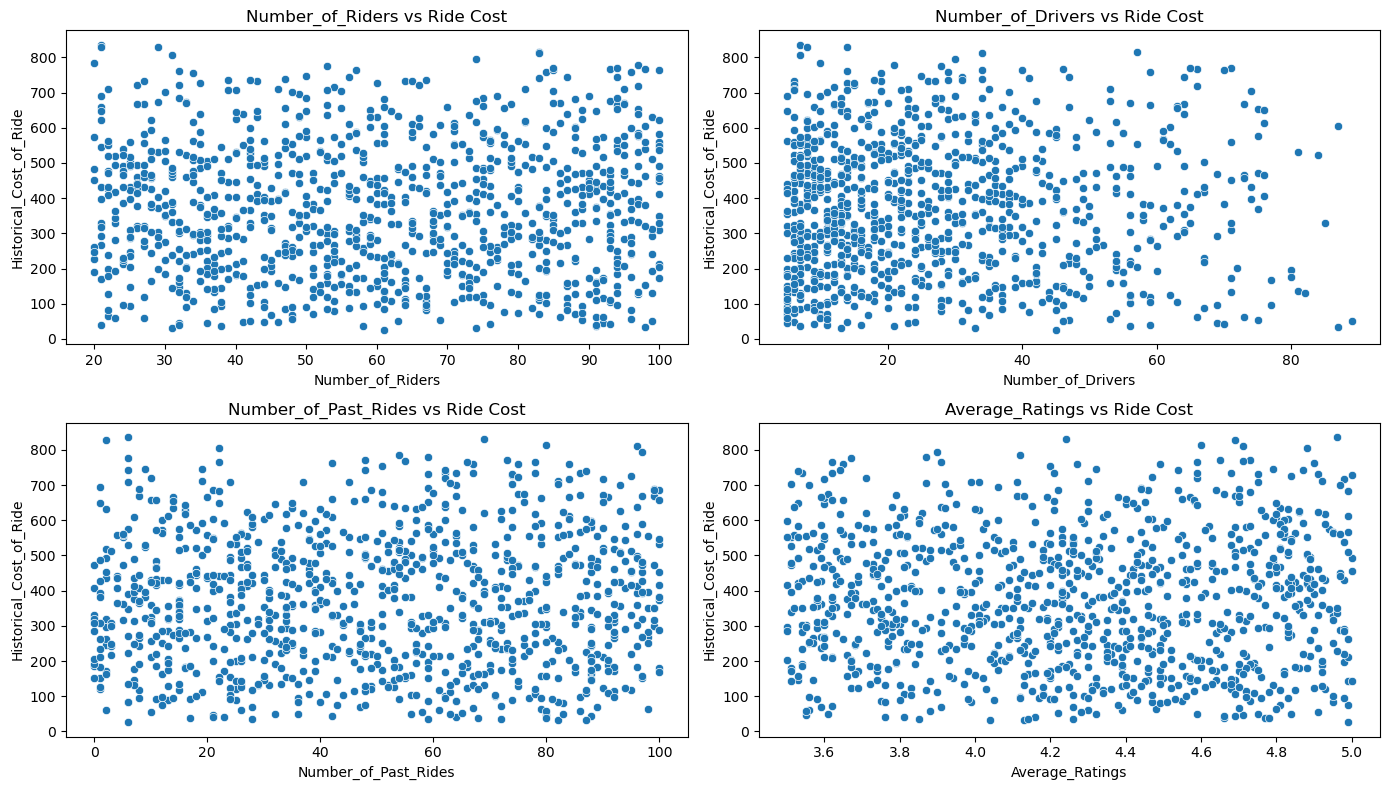

In [133]:
numerical_features = [
    'Number_of_Riders',
    'Number_of_Drivers',
    'Number_of_Past_Rides',
    'Average_Ratings'
]
mm.figure(figsize=(14,8))
for i, col in enumerate(numerical_features, 1):
    mm.subplot(2,2,i)
    sns.scatterplot(
        x=df[col],
        y=df['Historical_Cost_of_Ride']
    )

    mm.title(f'{col} vs Ride Cost')
mm.tight_layout()
mm.show()

# most relationships look random and highly scattered.
- The number of riders does not exhibit a clear direct relationship with ride cost.
- Driver availability alone does not appear to directly influence historical ride cost.
- Customer ride history does not demonstrate a meaningful relationship with ride cost.
- Customer ratings have negligible impact on pricing.

### Numerical Features vs Ride Cost

Scatter plots were used to examine the relationship between numerical variables and ride cost.

Most features, including `Number_of_Riders`, `Number_of_Drivers`, `Number_of_Past_Rides`, and `Average_Ratings`, displayed highly scattered and random distributions with no clear linear trend.

This observation aligns with the weak correlation coefficients observed earlier, suggesting these variables may not independently influence pricing in a linear manner. However, they may still contribute through non-linear interactions, which can be captured by advanced machine learning models.

# categorical variable analysis.

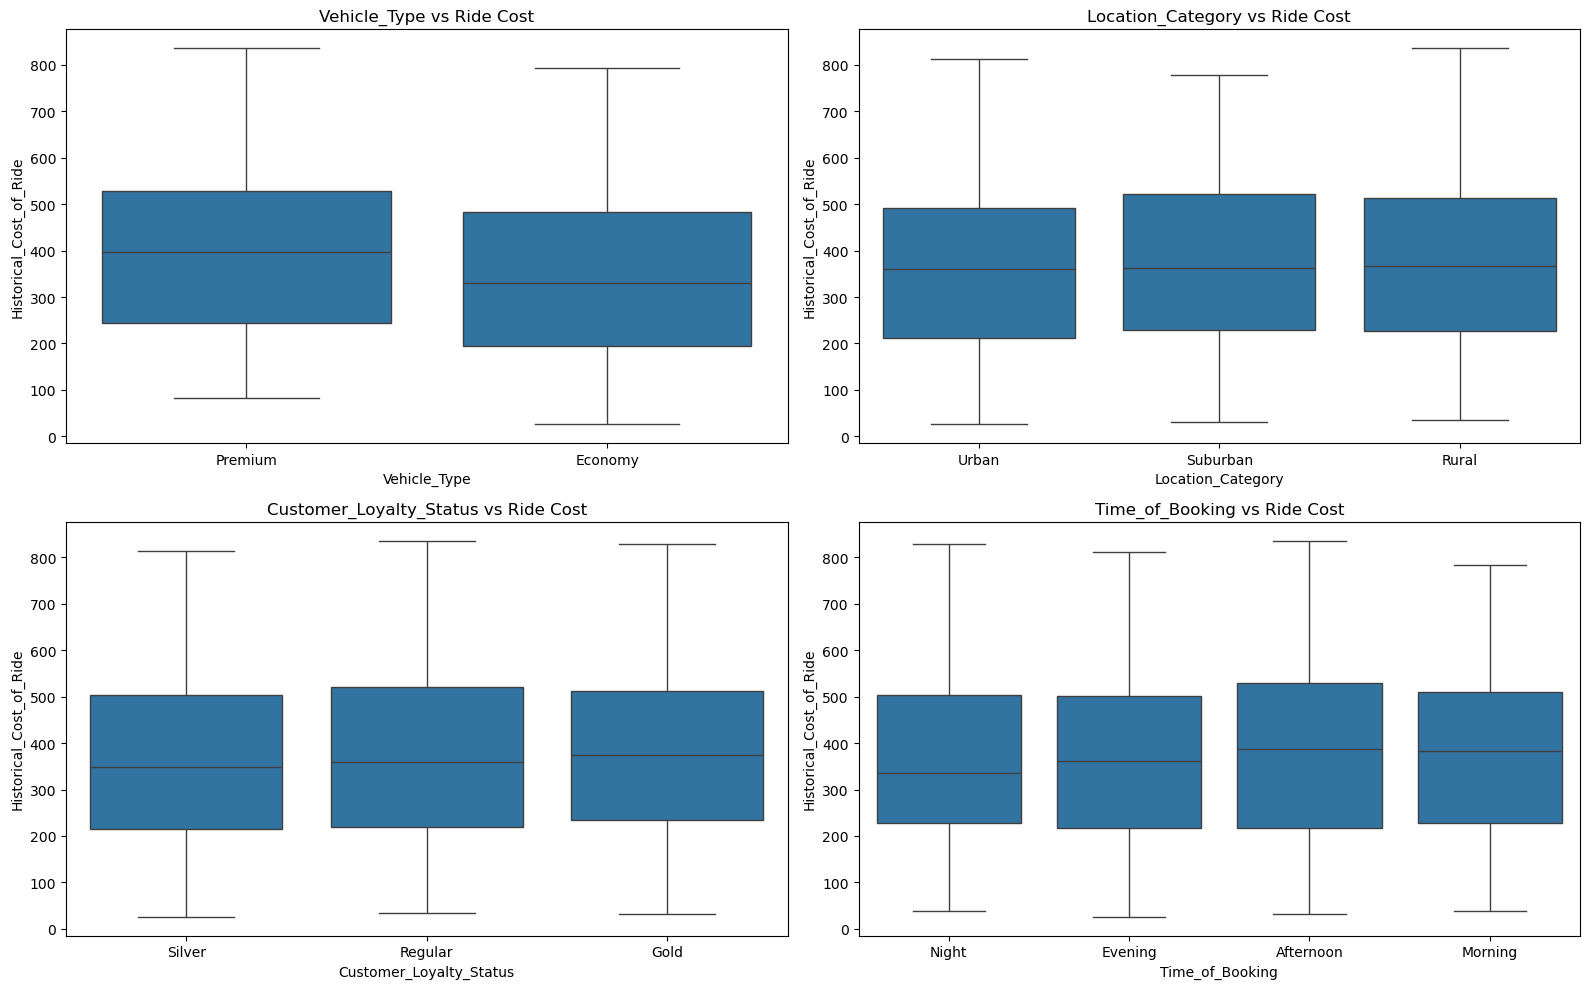

In [134]:
categorical_cols = [
    'Vehicle_Type',
    'Location_Category',
    'Customer_Loyalty_Status',
    'Time_of_Booking'
]
mm.figure(figsize=(16,10))
for i, col in enumerate(categorical_cols, 1):
    mm.subplot(2,2,i)
    sns.boxplot(
        x=df[col],
        y=df['Historical_Cost_of_Ride']
    )

    mm.title(f'{col} vs Ride Cost')

mm.tight_layout()
mm.show()

# Observation 
- Premium vehicle type has slightly higher ride cost then economy
We cannot trust our eyes alone. so we will do statistical Testing

# Statistical Testing

In [135]:
# since Vehicle_Type has only two categories we can use T-test
# we are asking: Does vehicle type affect ride cost?
# H0: There is NO significant difference in average ride cost between Economy and Premium vehicles.
from scipy.stats import ttest_ind
economy = df[df['Vehicle_Type'] == 'Economy']['Historical_Cost_of_Ride']
premium = df[df['Vehicle_Type'] == 'Premium']['Historical_Cost_of_Ride']
t_stat, p_value = ttest_ind(
    economy,
    premium
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -4.227610458312147
P-value: 2.578555908902287e-05


### T-Test: Vehicle Type vs Ride Cost

An independent T-test was conducted to determine whether vehicle type significantly affects ride cost.

#### Hypotheses:
- **H₀:** There is no significant difference in ride cost between Economy and Premium vehicles.
- **H₁:** There is a significant difference in ride cost between Economy and Premium vehicles.

The test produced a p-value of **0.000025**, which is less than the significance level (0.05).

Therefore, the null hypothesis was rejected, indicating that vehicle type has a statistically significant impact on ride cost. Premium vehicles tend to have higher ride costs than Economy vehicles.

In [136]:
from scipy.stats import f_oneway
# Time of Booking
groups = [
    group['Historical_Cost_of_Ride'].values
    for name, group in df.groupby('Time_of_Booking')
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.4629626041284672
P-value: 0.7082051942509269


### ANOVA: Time of Booking vs Ride Cost

A one-way ANOVA test was conducted to determine whether booking time significantly influences ride cost.

#### Hypotheses:
- **H₀:** Mean ride cost is equal across all booking times.
- **H₁:** At least one booking time has a different mean ride cost.

The ANOVA test produced a p-value of **0.708**, which is greater than the significance level (0.05).

Therefore, the null hypothesis could not be rejected, indicating that booking time does not significantly influence ride cost in this dataset.

In [137]:
# with Location Category
from scipy.stats import f_oneway
# Time of Booking
groups = [
    group['Historical_Cost_of_Ride'].values
    for name, group in df.groupby('Location_Category')
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.6620347711764132
P-value: 0.5160273293013125


In [138]:
# with Customer_Loyalty_Status
from scipy.stats import f_oneway
# Time of Booking
groups = [
    group['Historical_Cost_of_Ride'].values
    for name, group in df.groupby('Customer_Loyalty_Status')
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.819534651858085
P-value: 0.4409332695228039


# EDA Final Summary (What we discovered)
- Strong Predictor
->Expected_Ride_Duration
Very strong correlation (0.928)
Strong scatter relationship
Main driver of pricing

- Significant Categorical Variable
->Vehicle_Type
T-test significant
Premium rides cost more


- Weak / Non-significant Variables

❌ Time_of_Booking
❌ Location_Category
❌ Possibly Customer_Loyalty_Status
❌ Ratings, riders, drivers, past rides (weak linear effect)

Important insight:
Some weak variables may still help in machine learning through non-linear interactions.

In [139]:
df['Demand_Supply_Ratio'] = (
    df['Number_of_Riders']
    /
    df['Number_of_Drivers']
)

df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Demand_Supply_Ratio
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,2.000000
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,1.487179
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,1.354839
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232,3.178571
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422,3.545455


In [140]:
df.corr(numeric_only=True)[
    'Historical_Cost_of_Ride'
].sort_values(ascending=False)# Demand_Supply_Ratio -0.094372 not usefull 

Historical_Cost_of_Ride    1.000000
Expected_Ride_Duration     0.927547
Number_of_Past_Rides       0.035859
Number_of_Drivers          0.017082
Number_of_Riders           0.005826
Average_Ratings           -0.001063
Demand_Supply_Ratio       -0.094372
Name: Historical_Cost_of_Ride, dtype: float64

In [141]:
if 'Demand_Supply_Ratio' in df.columns:
    df.drop(
        'Demand_Supply_Ratio',
        axis=1,
        inplace=True
    )
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


# Data Preprocessing (for Modeling)
- Why preprocessing?

Machine learning models cannot directly understand:

Premium
Urban
Morning
Gold

We must convert them into numbers.

In [142]:
X = df.drop('Historical_Cost_of_Ride', axis=1)
y = df['Historical_Cost_of_Ride']

In [143]:
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(exclude='object').columns
print(categorical_features)
print(numerical_features)

Index(['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking',
       'Vehicle_Type'],
      dtype='object')
Index(['Number_of_Riders', 'Number_of_Drivers', 'Number_of_Past_Rides',
       'Average_Ratings', 'Expected_Ride_Duration'],
      dtype='object')


In [144]:
# categorical → encode
# numerical → keep as is
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(transformers=[(
            'cat',
            OneHotEncoder(drop='first',handle_unknown='ignore'),#handle_unknown='ignore' prevents crash for unseen data
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [145]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)

In [146]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [147]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(800, 13)
(200, 13)


In [148]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(
    X_train_processed,
    y_train
)

LinearRegression()

In [149]:
y_pred_lr = lr_model.predict(
    X_test_processed
)

In [150]:
# Evaluting 
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
mae = mean_absolute_error(
    y_test,
    y_pred_lr
)
mse = mean_squared_error(
    y_test,
    y_pred_lr
)
rmse = mse ** 0.5
r2 = r2_score(
    y_test,
    y_pred_lr
)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 52.56191768454384
MSE: 4548.60080855097
RMSE: 67.44331552163617
R² Score: 0.8752468282750773


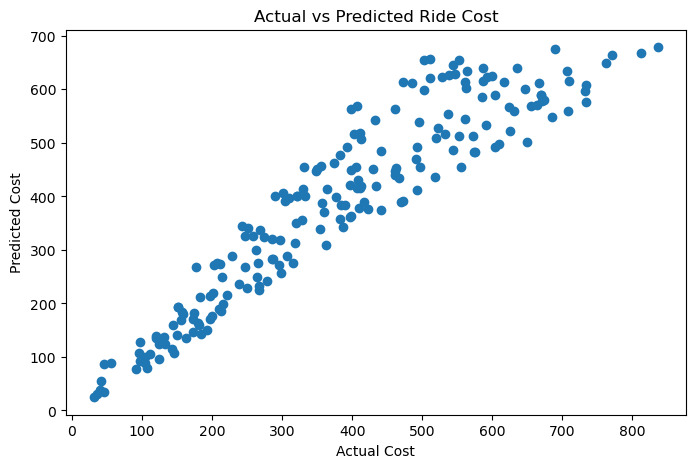

In [151]:
mm.figure(figsize=(8,5))
mm.scatter(
    y_test,
    y_pred_lr
)
mm.xlabel("Actual Cost")
mm.ylabel("Predicted Cost")
mm.title(
    "Actual vs Predicted Ride Cost"
)

mm.show()

In [152]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(
    X_train_processed,
    y_train
)

RandomForestRegressor(random_state=42)

In [153]:
y_pred_rf = rf_model.predict(
    X_test_processed
)

In [154]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)
rmse_rf = (
    mean_squared_error(
        y_test,
        y_pred_rf
    ) ** 0.5
)
r2_rf = r2_score(
    y_test,
    y_pred_rf
)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MAE: 55.03673133710627
RMSE: 73.35292939866092
R² Score: 0.8524263916401008


In [155]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(
    random_state=42
)
gb_model.fit(
    X_train_processed,
    y_train
)
y_pred_gb = gb_model.predict(
    X_test_processed
)
print("MAE:",
      mean_absolute_error(y_test, y_pred_gb))
print("RMSE:",
      mean_squared_error(
          y_test,
          y_pred_gb
      ) ** 0.5)

print("R² Score:",
      r2_score(
          y_test,
          y_pred_gb
      ))

MAE: 54.05682720535329
RMSE: 72.25533292222302
R² Score: 0.8568097047556045


### Model Comparison

Two regression models were evaluated:

1. Linear Regression  
2. Random Forest Regressor

Linear Regression achieved the best performance:

- **MAE:** 52.56
- **RMSE:** 67.44
- **R² Score:** 0.875

Random Forest achieved slightly lower performance, suggesting that the pricing structure in the dataset is predominantly linear.

Therefore, **Linear Regression was selected as the final model** due to its superior predictive performance and interpretability.

In [156]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['cat__Location_Category_Suburban', 'cat__Location_Category_Urban',
       'cat__Customer_Loyalty_Status_Regular',
       'cat__Customer_Loyalty_Status_Silver',
       'cat__Time_of_Booking_Evening', 'cat__Time_of_Booking_Morning',
       'cat__Time_of_Booking_Night', 'cat__Vehicle_Type_Premium',
       'remainder__Number_of_Riders', 'remainder__Number_of_Drivers',
       'remainder__Number_of_Past_Rides', 'remainder__Average_Ratings',
       'remainder__Expected_Ride_Duration'], dtype=object)

In [157]:
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})

coefficients

,Feature,Coefficient
0,cat__Location_Category_Suburban,-3.176077
1,cat__Location_Category_Urban,-4.005350
2,cat__Customer_Loyalty_Status_Regular,3.578693
3,cat__Customer_Loyalty_Status_Silver,4.987830
4,cat__Time_of_Booking_Evening,-5.163414
5,cat__Time_of_Booking_Morning,0.433219
6,cat__Time_of_Booking_Night,-2.421640
7,cat__Vehicle_Type_Premium,42.727863
8,remainder__Number_of_Riders,-0.040834
9,remainder__Number_of_Drivers,0.473769


In [158]:
coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
7,cat__Vehicle_Type_Premium,42.727863
11,remainder__Average_Ratings,7.294497
3,cat__Customer_Loyalty_Status_Silver,4.987830
2,cat__Customer_Loyalty_Status_Regular,3.578693
12,remainder__Expected_Ride_Duration,3.533110
9,remainder__Number_of_Drivers,0.473769
5,cat__Time_of_Booking_Morning,0.433219
10,remainder__Number_of_Past_Rides,0.023371
8,remainder__Number_of_Riders,-0.040834
6,cat__Time_of_Booking_Night,-2.421640


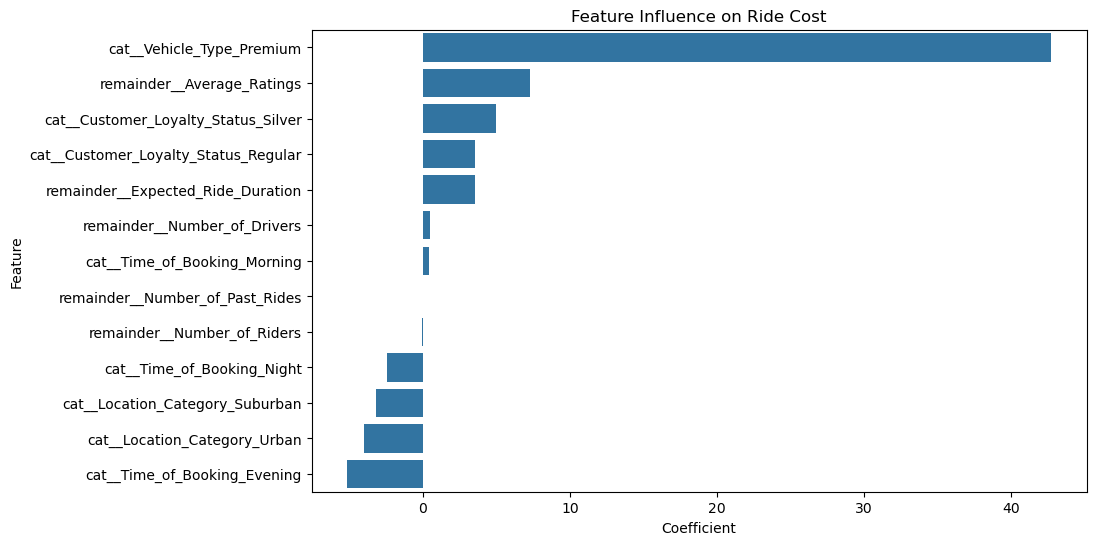

In [159]:
mm.figure(figsize=(10,6))

sns.barplot(
    data=coefficients,
    x='Coefficient',
    y='Feature'
)

mm.title(
    "Feature Influence on Ride Cost"
)

mm.show()

In [160]:
residuals = y_test - y_pred_lr

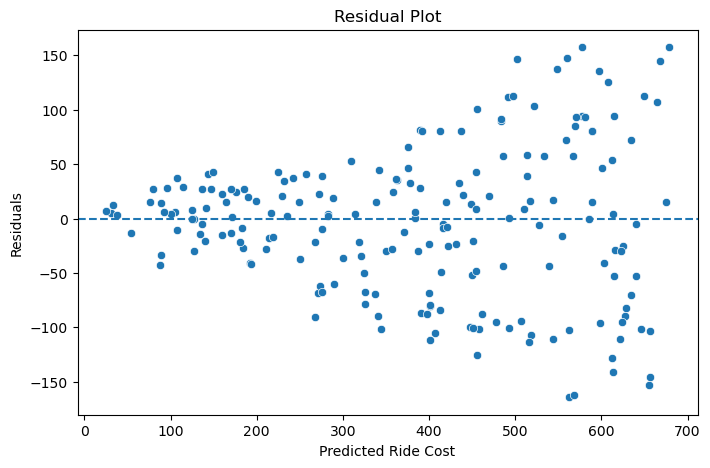

In [161]:
mm.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred_lr,
    y=residuals
)

mm.axhline(
    y=0,
    linestyle='--'
)

mm.xlabel("Predicted Ride Cost")
mm.ylabel("Residuals")

mm.title("Residual Plot")

mm.show()

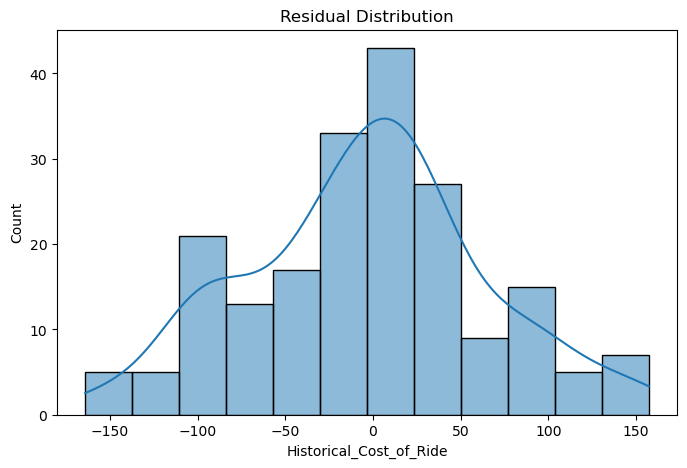

In [162]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

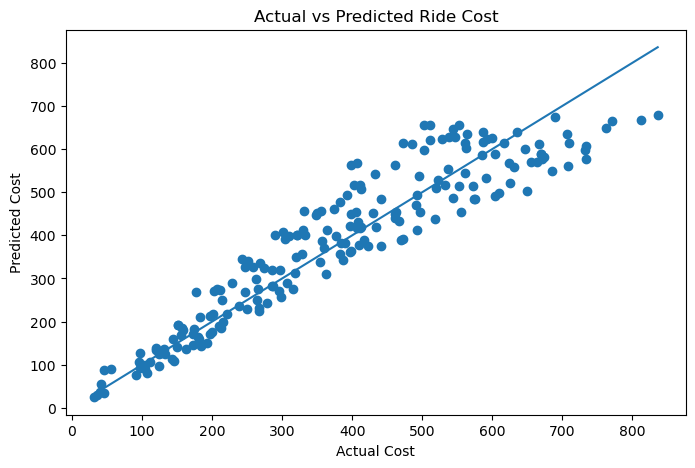

In [163]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_lr
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")

plt.title(
    "Actual vs Predicted Ride Cost"
)

plt.show()

### Residual Analysis

Residual analysis was performed to evaluate model performance and regression assumptions.

#### Actual vs Predicted Analysis
Predicted ride costs closely followed actual values, indicating good predictive performance.

#### Residual Distribution
Residuals were approximately centered around zero and showed a near-normal distribution, suggesting balanced prediction errors.

#### Residual Plot
A mild heteroscedasticity pattern was observed, where residual variance increased for higher predicted ride costs. This suggests that the model performs slightly less consistently for expensive rides.

Overall, the residual analysis indicates that Linear Regression provides a strong fit for the dataset despite minor variability at higher ride costs.

# Save the Model

In [164]:
import joblib

joblib.dump(lr_model,"dynamic_pricing_model.pkl")
joblib.dump(preprocessor,"preprocessor.pkl")

['preprocessor.pkl']